cluster-notebook.ipynb

## Steps

K-means 1: Create Cluster Pipeline 
- data cleaning 
- feature engineering
- feature scaling
- PCA
- KMeans Cluster Model

K-means 2: PCA components number?

K-means 3: Elbow Method and Silhouette score 
- define the number of clusters in Cluster Pipeline

K-means 4: Fit cluster pipeline

K-means 5: Add cluster predictions to data

K-means 6: Create Classifier Pipeline 
- separate pipeline where the target variable is cluster predictions and features are the remaining variables

K-means 7: Fit classifier
- evaluate its performance and assess the most important features

K-means 8: Cluster analysis
- explain each cluster profile in terms of the most important features


In [43]:
# import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [44]:
df = pd.read_csv("C:\\Users\\beth_\\Documents\\health-insurance\\health-insurance-project-1\\Iris-Clustering\\data\\data_clean.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


The Code Institute notebook I am referring to during this algorithm uses the Iris dataset directly from sklearn. 
Therefore I will adapt the kaggle data to behave like the sklearn dataset: with attributes (features names and target).

In [45]:
X = df.drop(["Id", "Species"], axis=1)   # features
y = df["Species"]                # target

In [46]:
feature_names = X.columns.tolist()
data_array = X.values
target = y.values

In [47]:
# chatgpt suggested using a Bunch object to store the data, feature names, and target. 
# This is a common practice in machine learning projects to keep the data organized and easily accessible.

class Bunch:
    def __init__(self, data, feature_names, target):
        self.data = data
        self.feature_names = feature_names
        self.target = target

data = Bunch(data_array, feature_names, target)

In [48]:
df2 = pd.DataFrame(data.data, columns=data.feature_names)
df2.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [49]:
from sklearn.preprocessing import LabelEncoder

# encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Now we are ready to start work on the pipeline. Remembering to use
- df2
- x
- y_encoded

## Step 1: create ML cluster pipeline

In [50]:
from sklearn.pipeline import Pipeline

# Data Cleaning
from feature_engine.imputation import MeanMedianImputer

# Feat Scaling
from sklearn.preprocessing import StandardScaler

# PCA
from sklearn.decomposition import PCA

# ML algorithm
from sklearn.cluster import KMeans

# create pipeline
# the values of n_components and n_clusters are arbitrary, we will find the optimal values in the next steps

def PipelineCluster():
  pipeline_base = Pipeline([
                            
      ( 'MeanMedianImputer', MeanMedianImputer(imputation_method='median') ),

      ("scaler", StandardScaler()  ),    

      ("PCA",  PCA(n_components=20, random_state=0)), 

      ("model", KMeans(n_clusters=20, random_state=0)  ), 
  ])
  return pipeline_base

PipelineCluster()

Pipeline(steps=[('MeanMedianImputer', MeanMedianImputer()),
                ('scaler', StandardScaler()),
                ('PCA', PCA(n_components=20, random_state=0)),
                ('model', KMeans(n_clusters=20, random_state=0))])

## Step 2: Principal Component Analysis

PCA transforms the data and tries to determine what features explain the most variance.

After the transformation, it creates a set of components (less than the number of variables), where each component contains the relevant information from the original variables.

The optimum number of n_components needs to be found as this will impact the algorithm's performance. 

In [51]:
pipeline_cluster = PipelineCluster()
pipeline_pca = Pipeline(pipeline_cluster.steps[:-2])
df_pca = pipeline_pca.fit_transform(df2)

print(df_pca.shape,'\n', type(df_pca))

(150, 4) 
 <class 'numpy.ndarray'>


In [52]:
n_components = 4 # set the number of components as all columns in the data

pca = PCA(n_components=n_components).fit(df_pca)  # set PCA object and fit to the data
x_PCA = pca.transform(df_pca) # array with transformed PCA


# the PCA object has .explained_variance_ratio_ attribute, which tells 
# how much information (variance) each component has 

# we store that to a DataFrame relating each component to its variance explanation
ComponentsList = ["Component " + str(number) for number in range(n_components)]
dfExplVarRatio = pd.DataFrame(
    data= np.round(100 * pca.explained_variance_ratio_ ,3),
    index=ComponentsList,
    columns=['Explained Variance Ratio (%)'])

# print how much of the dataset these components explain
PercentageOfData = dfExplVarRatio['Explained Variance Ratio (%)'].sum()

print(f"* The {n_components} components explain {round(PercentageOfData,2)}% of the data \n")
print(dfExplVarRatio)

* The 4 components explain 100.0% of the data 

             Explained Variance Ratio (%)
Component 0                        72.770
Component 1                        23.031
Component 2                         3.684
Component 3                         0.515


In [53]:
def PipelineCluster():
  pipeline_base = Pipeline([
                            
      ( 'MeanMedianImputer', MeanMedianImputer(imputation_method='median') ),

      ("scaler", StandardScaler()  ),    

      ("PCA",  PCA(n_components=4, random_state=0)),  ##### we update the n_components to 4

      ("model", KMeans(n_clusters=10, random_state=0)  ), 
  ])
  return pipeline_base

PipelineCluster()

Pipeline(steps=[('MeanMedianImputer', MeanMedianImputer()),
                ('scaler', StandardScaler()),
                ('PCA', PCA(n_components=4, random_state=0)),
                ('model', KMeans(n_clusters=10, random_state=0))])

## Step 3: Elbow method and silhouette score: 

Use these two methods to find the optimum number of clusters (we expect there to be three clusters as there are three types of iris in the data).
Yellowbrick is useful here. 

In [54]:
pipeline_cluster = PipelineCluster()
pipeline_analysis = Pipeline(pipeline_cluster.steps[:-1])
df_analysis = pipeline_analysis.fit_transform(df2)

print(df_analysis.shape,'\n', type(df_analysis))

(150, 4) 
 <class 'numpy.ndarray'>


c:\Users\beth_\Documents\health-insurance\health-insurance-project-1\Iris-Clustering\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\beth_\Documents\health-insurance\health-insurance-project-1\Iris-Clustering\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\beth_\Documents\health-insurance\health-insurance-project-1\Iris-Clustering\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input

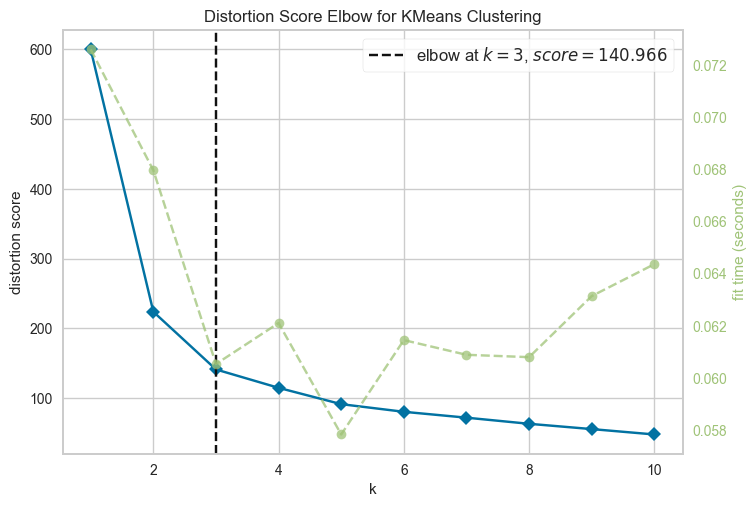

In [55]:
# install setuptools to configure yellowbrick (future warnings)
from yellowbrick.cluster import KElbowVisualizer

# using the k-means algorithm, we will find the optimal number of clusters for our data using the elbow method.
visualizer = KElbowVisualizer(KMeans(random_state=0), k=(1,11))
visualizer.fit(df_analysis) 
visualizer.show() 
plt.show()

The Elbow Method suggests that 3 is the optimal numbers of clusters.

We will also use the Silhouette Method from the Yellow Brick library. 

=== Average Silhouette Score for different numbers of clusters ===


c:\Users\beth_\Documents\health-insurance\health-insurance-project-1\Iris-Clustering\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\beth_\Documents\health-insurance\health-insurance-project-1\Iris-Clustering\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\beth_\Documents\health-insurance\health-insurance-project-1\Iris-Clustering\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input

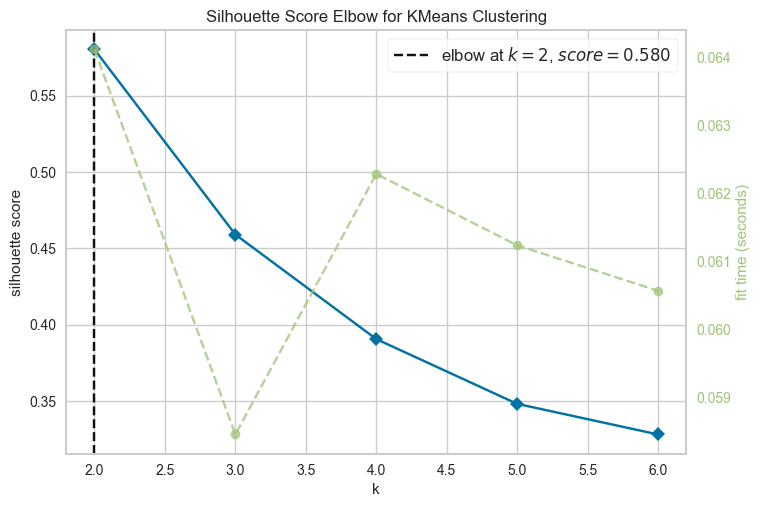



=== Silhouette plot for 2 Clusters ===


c:\Users\beth_\Documents\health-insurance\health-insurance-project-1\Iris-Clustering\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


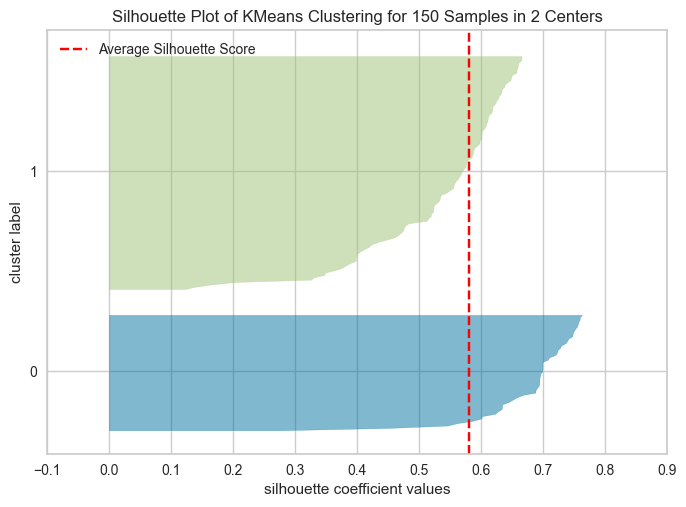



=== Silhouette plot for 3 Clusters ===


c:\Users\beth_\Documents\health-insurance\health-insurance-project-1\Iris-Clustering\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


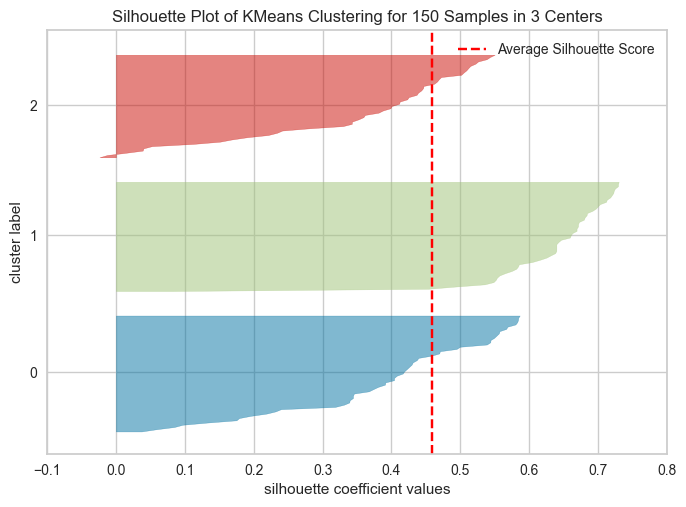



=== Silhouette plot for 4 Clusters ===


c:\Users\beth_\Documents\health-insurance\health-insurance-project-1\Iris-Clustering\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


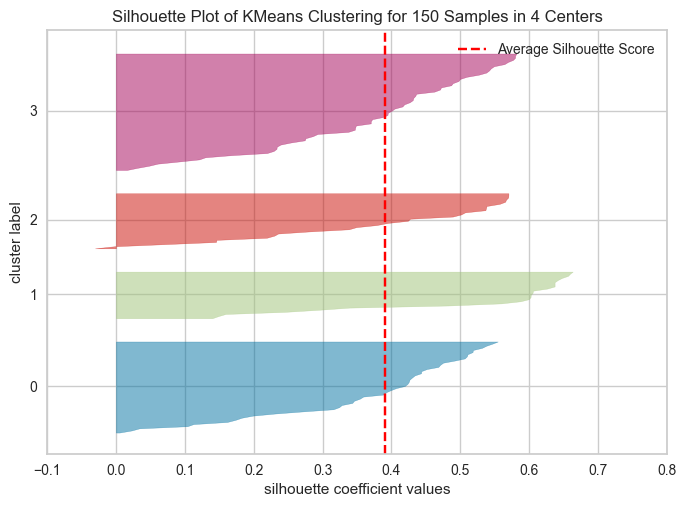



=== Silhouette plot for 5 Clusters ===


c:\Users\beth_\Documents\health-insurance\health-insurance-project-1\Iris-Clustering\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


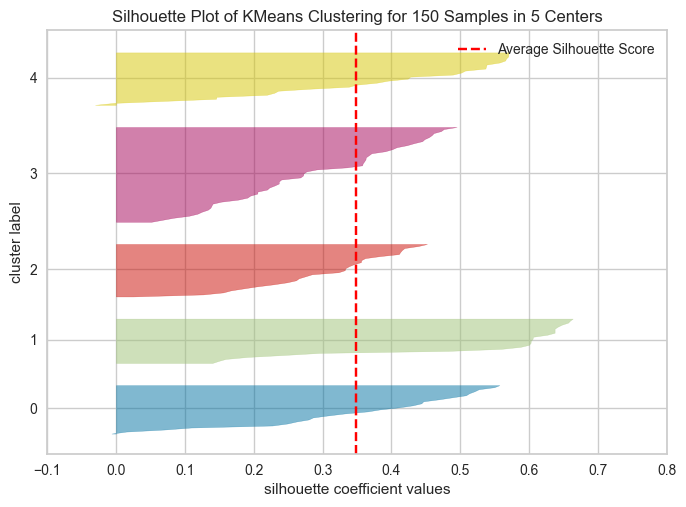



=== Silhouette plot for 6 Clusters ===


c:\Users\beth_\Documents\health-insurance\health-insurance-project-1\Iris-Clustering\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


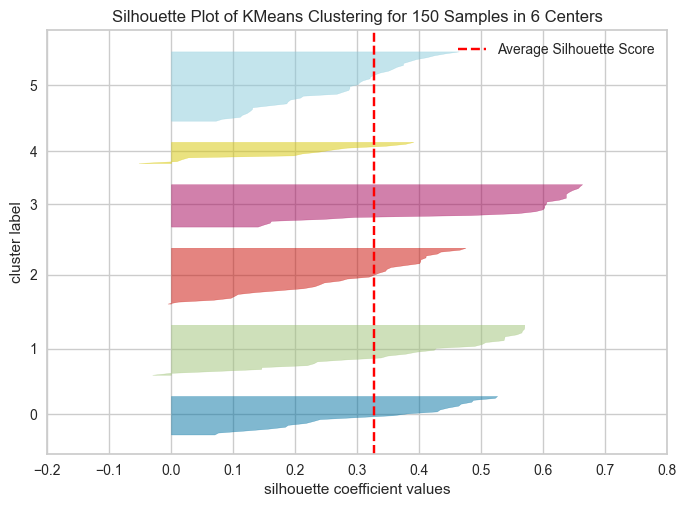

In [56]:
from yellowbrick.cluster import SilhouetteVisualizer

print("=== Average Silhouette Score for different numbers of clusters ===")
visualizer = KElbowVisualizer(KMeans(random_state=0), k=(2,7), metric='silhouette')
visualizer.fit(df_analysis) 
visualizer.show() 
plt.show()
print("\n")

for n_clusters in np.arange(start=2,stop=7):
  
  print(f"=== Silhouette plot for {n_clusters} Clusters ===")
  visualizer = SilhouetteVisualizer(estimator = KMeans(n_clusters=n_clusters, random_state=0),
                                    colors = 'yellowbrick')
  visualizer.fit(df_analysis)
  visualizer.show()
  plt.show()
  print("\n")

The average silhouette score would suggest that two is the optimal number of clusters. However, looking at the silhouette plots the clusters profiles look best with **three** clusters and this agrees with the Elbow Method. 

## Step 4: Fit the Cluster Pipeline

In [57]:
# based on the elbow and silhouette analysis, we will set n_clusters to 3 in our pipeline and fit the model to the data.
def PipelineCluster3():
  pipeline_base = Pipeline([
                            
      ( 'MeanMedianImputer', MeanMedianImputer(imputation_method='median') ),

      ("scaler", StandardScaler()  ),    

      ("PCA",  PCA(n_components=4, random_state=0)),  # n_components is set to 4 based on the previous PCA analysis

      ("model", KMeans(n_clusters=3, random_state=0)  ), # n_clusters is set to 3 based on the previous elbow and silhouette analysis
  ])
  return pipeline_base

PipelineCluster3()

Pipeline(steps=[('MeanMedianImputer', MeanMedianImputer()),
                ('scaler', StandardScaler()),
                ('PCA', PCA(n_components=4, random_state=0)),
                ('model', KMeans(n_clusters=3, random_state=0))])

In [58]:
X = df2.copy() 
pipeline_cluster3 = PipelineCluster3()
pipeline_cluster3.fit(X)

c:\Users\beth_\Documents\health-insurance\health-insurance-project-1\Iris-Clustering\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Pipeline(steps=[('MeanMedianImputer', MeanMedianImputer()),
                ('scaler', StandardScaler()),
                ('PCA', PCA(n_components=4, random_state=0)),
                ('model', KMeans(n_clusters=3, random_state=0))])

## Step 5: Add Cluster Predictions to Data

In [59]:
# add the cluster labels to the original data
X['Clusters'] = pipeline_cluster3['model'].labels_
print(X.shape)
X.head()

(150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Clusters
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


* Clusters frequencies 
          proportion
Clusters            
0               0.35
1               0.33
2               0.31 




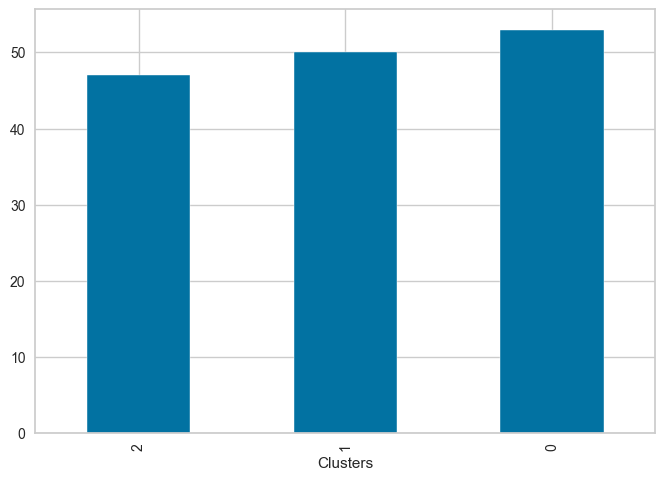

In [60]:
# plot the frequency of each cluster
print(f"* Clusters frequencies \n{ X['Clusters'].value_counts(normalize=True).to_frame().round(2)} \n\n")
X['Clusters'].value_counts().sort_values().plot(kind='bar')
plt.show()

From the EDA we know that there are 50 of each species of Iris. The clustering algorithm has done well! ...below we will find out exactly how well it has performed. 

## Step 6: Create Classifier Pipeline

We now need to interpret the clusters and the predictions from the pipeline. We can learn each cluster's profile by finding the most relevant variables. 

In [61]:
df_clf = X.copy()
print(df_clf.shape)
df_clf.head(3)

(150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Clusters
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1


In [62]:
# split the data into train and test sets
# we will use the cluster labels as the target variable and the original features as the input variables 
# to train a classification model in the next steps

from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(
                                    df_clf.drop(['Clusters'],axis=1),
                                    df_clf['Clusters'],
                                    test_size=0.2,
                                    random_state=0
                                    )

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(120, 4) (120,) (30, 4) (30,)


Please note that I am working through a Code Institute lesson but with a different dataset. Some of my steps might seem to overlap as I am learning. 

The Gradient Boost Classifier is a good choice here as it is fast to train and straightforward to use. 

In [63]:
### Feat Selection
from sklearn.feature_selection import SelectFromModel

### ML algorithm
from sklearn.ensemble import GradientBoostingClassifier 

def PipelineClf2ExplainClusters():
  pipeline_base = Pipeline([
                            
      ( 'MeanMedianImputer', MeanMedianImputer(imputation_method='median',) ),

      ("scaler", StandardScaler()  ),    

      ("feat_selection", SelectFromModel(GradientBoostingClassifier(random_state=0)) ), 

      ("model",  GradientBoostingClassifier(random_state=0) ), 
  ])
  return pipeline_base

  
PipelineClf2ExplainClusters()

Pipeline(steps=[('MeanMedianImputer', MeanMedianImputer()),
                ('scaler', StandardScaler()),
                ('feat_selection',
                 SelectFromModel(estimator=GradientBoostingClassifier(random_state=0))),
                ('model', GradientBoostingClassifier(random_state=0))])

## Step 7: Fit Classifier

In [64]:
# fit the classification model to the data
pipeline_clf_cluster = PipelineClf2ExplainClusters()
pipeline_clf_cluster.fit(X_train, y_train)

Pipeline(steps=[('MeanMedianImputer', MeanMedianImputer()),
                ('scaler', StandardScaler()),
                ('feat_selection',
                 SelectFromModel(estimator=GradientBoostingClassifier(random_state=0))),
                ('model', GradientBoostingClassifier(random_state=0))])

Now we will evaluate the classifier's performance. 

In [65]:
# evaluate the model on the training data
from sklearn.metrics import classification_report
print(classification_report(y_train, pipeline_clf_cluster.predict(X_train)))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        39
           1       1.00      1.00      1.00        39
           2       0.98      0.95      0.96        42

    accuracy                           0.97       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.97      0.98       120



In [66]:
# evaluate the model on the test data
print(classification_report(y_test, pipeline_clf_cluster.predict(X_test)))

              precision    recall  f1-score   support

           0       0.92      0.79      0.85        14
           1       1.00      1.00      1.00        11
           2       0.57      0.80      0.67         5

    accuracy                           0.87        30
   macro avg       0.83      0.86      0.84        30
weighted avg       0.89      0.87      0.87        30



Evaluation: 

The model got 87% of all predictions correct (26 out of 30 samples).

Cluster 0 performs well, Cluster 1 is perfect but Cluster 2 is struggling. This could be because the sample size for cluster 2 in the test set is small. 

How the scores could be improved:
- Increase size of the training data
- Try a different model or tuning to improve recall

What are the most important features that define a cluster?

In [67]:
pipeline_clf_cluster

Pipeline(steps=[('MeanMedianImputer', MeanMedianImputer()),
                ('scaler', StandardScaler()),
                ('feat_selection',
                 SelectFromModel(estimator=GradientBoostingClassifier(random_state=0))),
                ('model', GradientBoostingClassifier(random_state=0))])

* These are the 2 most important features in descending order. The model was trained on them: 
['PetalWidthCm', 'SepalLengthCm'] 



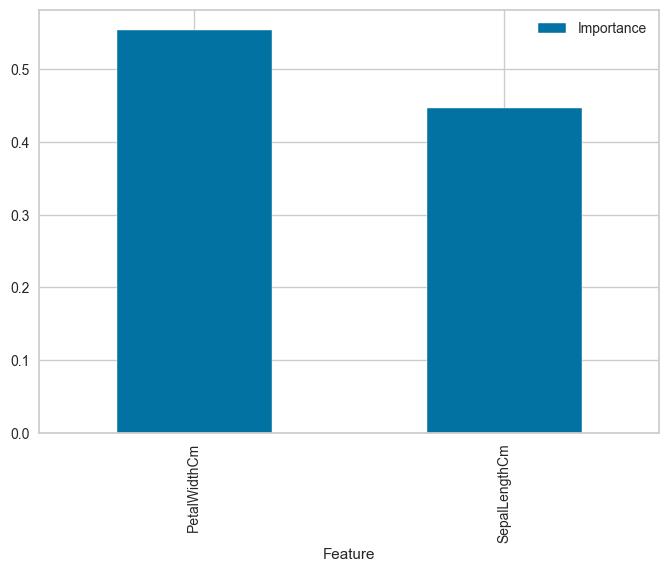

In [68]:
# after data cleaning and feat engineering, the feature space changes

data_cleaning_feat_eng_steps = 1 # how many data cleaning and feature engineering steps does your pipeline have?
columns_after_data_cleaning_feat_eng = (Pipeline(pipeline_clf_cluster.steps[:data_cleaning_feat_eng_steps])
                                        .transform(X_train)
                                        .columns)

best_features = columns_after_data_cleaning_feat_eng[pipeline_clf_cluster['feat_selection'].get_support()].to_list()

# create DataFrame to display feature importance
df_feature_importance = (pd.DataFrame(data={
          'Feature': columns_after_data_cleaning_feat_eng[pipeline_clf_cluster['feat_selection'].get_support()],
          'Importance': pipeline_clf_cluster['model'].feature_importances_})
  .sort_values(by='Importance', ascending=False)
  )

best_features = df_feature_importance['Feature'].to_list() # reassign best features in importance order

# Most important features statement and plot
print(f"* These are the {len(best_features)} most important features in descending order. "
      f"The model was trained on them: \n{best_features} \n")
df_feature_importance.plot(kind='bar',x='Feature',y='Importance')
plt.show()

The Classifier has discovered that the two most important features are **Petal Width** and **Sepal Length**. 